## Pipeline para coleta do acervo

Em pipeline.ipynb você encontrará outra maneira de utilizar a ferramenta: ao fazer ferramente.py, você pode escolher entre o uso direto dos métodos através de comandos digitados no terminal, ou montá-los passo a passo com o uso do terminal interativo. Aqui você poderá ver uma pipeline completa dos comandos, desde obter os registros à obter suas imagens, assim como gráficos ilustrando seus resultados.

In [1]:
from bibliotecas import *

configurar()

(<main_f.species_link at 0x201019cc190>,
 {'user': 'root',
  'password': 'root',
  'host': '127.0.0.1',
  'database': 'teste_pipeline'})

#### Terceira etapa: filtragem de estado

In [10]:
conn = mysql.connector.connect(**db_config)
cursor = conn.cursor()

requisito = "country_att" # < troque pelo nome da tabela que você utilizou anteriormente para armazenar o país filtrado
coluna = "stateprovince"
table = table

sql = f"""SELECT {coluna} FROM {table} WHERE {coluna} IS NOT NULL AND {requisito} IS NOT NULL GROUP BY {coluna}"""

cursor.execute(sql)
resultados = cursor.fetchall()

for resultado in resultados:
    print(resultado[0])

cursor.close()
conn.close()  

MG
Santa Catarina
Rio de Janeiro
Minas Gerais
Bahia
Goias
Mato Grosso
Ceará
Piaui
Maranhão
MA
Amapá
Alagoas
Pernambuco
Rio Grande do Norte
Sergipe
Paraíba
ES
PI
Pará
Acre
SÃ£o Paulo
CearÃ¡
São Paulo
ParaÃ­ba
ParanÃ¡
Rio Grande do Sul
Paraná
Rondônia
Distrito Federal
Roraima
Amazonas
Tocantins
Mato Grosso do Sul
RS
SC
PE
Espírito Santo
Fernando de Noronha
MaranhÃ£o
BA
PR
RJ
MS
SP
CE
PA
MT
Unknown
Rio Branco
GO
Pernanbuco
DF
TO
PB
RO
Alegrete
Matogroso do Sul
AC
AL
Estado Não Informado!
ESPÍRITO SANTO, ES
BAHIA, BA
Paraná 
MINAS GERAIS, MG
Brasília
Sairé


Novamente, a filtragem dos valores que você busca deverá ser feita manualmente, e preenchida no pipeline. No meu caso, separarei pelos estados brasileiros e unificarei em um único nome. Vou utilizar de mapeamento para atualizar os valores:

In [11]:
STATE_MAP = {
    "Rio de Janeiro": [
        "Rio de Janeiro",
        "RJ",
    ],
    "Minas Gerais": [
        "Minas Gerais",
        "MG",
        "MINAS GERAIS, MG",
    ],
    "São Paulo": [
        "SP",
        "Sao Paulo",
        "São Paulo",
        "SÃ£o Paulo",
    ],
    "Santa Catarina": [
        "Santa Catarina",
        "SC",
    ],
    "Bahia": [
        "Bahia",
        "BA",
        "BAHIA, BA",
    ],
    "Goiás": [
        "Goias",
        "GO",
    ],
    "Mato Grosso": [
        "Mato Grosso",
        "MT",
    ],
    "Ceará": [
        "Ceará",
        "CearÃ¡",
        "CE",
    ],
    "Piaui": [
        "Piaui",
        "PI",
    ],
    "Maranhão": [
        "Maranhão",
        "MA",
       "MaranhÃ£o" ,
    ],
    "Amapá": [
        "Amapá",
    ],
    "Alagoas": [
        "Alagoas",
        "AL",
    ],
    "Pernambuco": [
        "Pernambuco",
        "PE",
        "Fernando de Noronha",
        "Pernanbuco",
        "Sairé",
    ],
    "Rio Grande do Norte": [
        "Rio Grande do Norte",
    ],
    "Sergipe": [
        "Sergipe",
    ],
    "Paraíba": [
        "Paraíba",
        "ParaÃ­ba",
        "PB",
    ],
    "Espírito Santo": [
        "Espírito Santo",
        "ES",
        "ESPÍRITO SANTO, ES",
    ],
    "Pará": [
        "Pará",
        "PA",
    ],
    "Acre": [
        "Acre",
        "Rio Branco",
        "AC",
    ],
    "Paraná": [
        "Parana",
        "Paraná",
        "ParanÃ¡",
        "PR",
    ],
    "Rio Grande do Sul": [
        "Rio Grande do Sul",
        "RS",
        "Alegrete",
    ],
    "Rondônia": [
        "Rondônia",
        "RO",
    ],
    "Distrito Federal": [
        "Distrito Federal",
        "DF",
        "Brasília",
    ],
    "Roraima": [
        "Roraima",
    ],
    "Amazonas": [
        "Amazonas",
    ],
    "Tocantins": [
        "Tocantins",
        "TO",
    ],
    "Mato Grosso do Sul": [
        "Mato Grosso do Sul",
        "MS",
        "Matogroso do Sul",
    ],
}


In [15]:
campo_input = input("informe o nome que voce deseja que o novo campo tenha (não crie o campo manualmente quando executando pelo pipeline!)").strip()
table = input("informe o nome da tabela de onde os registros serão atualizados: ").strip()
# print(f"executando specieslink.update_records(filters={filters_input}, update_values={update_input}, table={table})...\n")

for estado_padrao, variantes in STATE_MAP.items():
    for variante in variantes:
        update_input = f"{campo_input}={estado_padrao}"
        filters_input = f"stateprovince={variante}"

        print(f"executando specieslink.update_records(filters={filters_input}, update_values={update_input}, table={table})...\n")

        filtragem(campo_input=campo_input,update_input=update_input,filters_input=filters_input,table=table)


executando specieslink.update_records(filters=stateprovince=Rio de Janeiro, update_values=stateprovince_att=Rio de Janeiro, table=registros_biodiversidade)...

campo 'stateprovince_att' criado com sucesso na tabela 'registros_biodiversidade'
valor de atualização mal formatado: de - use chave=valor
executando specieslink.update_records(filters=stateprovince=RJ, update_values=stateprovince_att=Rio de Janeiro, table=registros_biodiversidade)...

campo 'stateprovince_att' já existe ou erro ao criar: 1060 (42S21): Duplicate column name 'stateprovince_att'
valor de atualização mal formatado: de - use chave=valor
executando specieslink.update_records(filters=stateprovince=Minas Gerais, update_values=stateprovince_att=Minas Gerais, table=registros_biodiversidade)...

campo 'stateprovince_att' já existe ou erro ao criar: 1060 (42S21): Duplicate column name 'stateprovince_att'
valor de atualização mal formatado: Gerais - use chave=valor
executando specieslink.update_records(filters=stateprovince

In [12]:
conn = mysql.connector.connect(**db_config)
cursor = conn.cursor()

sql = """
SELECT
    COUNT(*) AS total_registros,
    SUM(country_att IS NOT NULL) AS com_country,
    SUM(country_att IS NOT NULL AND stateprovince_att IS NOT NULL) AS com_country_e_state
FROM registros_biodiversidade
"""

cursor.execute(sql)
total_registros, registros_country, registros_country_state = cursor.fetchone()

cursor.close()
conn.close()

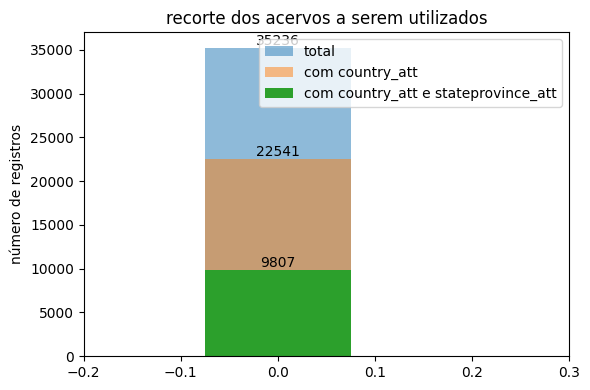

In [ ]:
plt.figure(figsize=(6, 4))

x = [0]

plt.bar(
    x,
    [total_registros],
    alpha=0.5,
    width=0.15,
    label='total'
)

plt.bar(
    x,
    [registros_country],
    alpha=0.5,
    width=0.15,
    label='com country_att'
)

plt.bar(
    x,
    [registros_country_state],
    width=0.15,
    label='com country_att e stateprovince_att'
)

plt.xlim(-0.2, 0.3)
plt.ylabel('número de registros')
plt.title('recorte dos acervos a serem utilizados')
plt.legend()

plt.text(0, total_registros, str(total_registros), ha='center', va='bottom')
plt.text(0, registros_country, str(registros_country), ha='center', va='bottom')
plt.text(0, registros_country_state, str(registros_country_state), ha='center', va='bottom')

plt.tight_layout()
plt.show()

#### Quarta etapa: filtragem do código de barras

In [22]:
campo_input = input("informe o nome que voce deseja que o novo campo tenha (não crie o campo manualmente quando executando pelo pipeline!)").strip()
original_input = input("informe o campo original do barcode: ").strip()
table = input("informe o nome da tabela de onde os registros serão atualizados: ").strip()

conn = mysql.connector.connect(**db_config)
cursor = conn.cursor()

sql = f"""
UPDATE {table}
SET {campo_input} = {original_input}
WHERE {original_input} IS NOT NULL
"""

cursor.execute(sql)
conn.commit()

cursor.close()
conn.close()


In [13]:
conn = mysql.connector.connect(**db_config)
cursor = conn.cursor()

sql = """
SELECT
    COUNT(*) AS total_registros,
    SUM(country_att IS NOT NULL) AS com_country,
    SUM(country_att IS NOT NULL AND stateprovince_att IS NOT NULL) AS com_country_e_state,
    SUM(country_att IS NOT NULL AND stateprovince_att IS NOT NULL AND barcode_att IS NOT NULL) as com_country_state_e_barcode
FROM registros_biodiversidade
"""

cursor.execute(sql)
total_registros, registros_country, registros_country_state, registros_country_state_barcode = cursor.fetchone()

cursor.close()
conn.close()

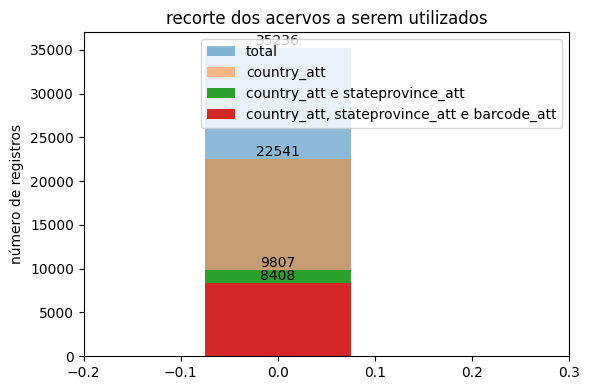

In [28]:
plt.figure(figsize=(6, 4))

x = [0]

plt.bar(
    x,
    [total_registros],
    alpha=0.5,
    width=0.15,
    label='total'
)

plt.bar(
    x,
    [registros_country],
    alpha=0.5,
    width=0.15,
    label='country_att'
)

plt.bar(
    x,
    [registros_country_state],
    width=0.15,
    label='country_att e stateprovince_att'
)

plt.bar(
    x,
    [registros_country_state_barcode],
    width=0.15,
    label='country_att, stateprovince_att e barcode_att'
)

plt.xlim(-0.2, 0.3)
plt.ylabel('número de registros')
plt.title('recorte dos acervos a serem utilizados')
plt.legend()

plt.text(0, total_registros, str(total_registros), ha='center', va='bottom')
plt.text(0, registros_country, str(registros_country), ha='center', va='bottom')
plt.text(0, registros_country_state, str(registros_country_state), ha='center', va='bottom')
plt.text(0, registros_country_state_barcode, str(registros_country_state_barcode), ha='center', va='bottom')

plt.tight_layout()
plt.show()

#### Quinta etapa: identificadores confiáveis

In [20]:
def identificadores(table, db_config):
    conn = mysql.connector.connect(**db_config)
    cursor = conn.cursor()

    requisito = "country_att" # < troque pelo nome da tabela que você utilizou anteriormente para armazenar o país filtrado
    requisito2 = "stateprovince_att"
    requisito3 = "barcode_att"
    coluna = "identifiedby"

    sql = f"""SELECT {coluna} FROM {table} WHERE {coluna} IS NOT NULL AND {requisito} IS NOT NULL AND {requisito2} IS NOT NULL AND {requisito3} IS NOT NULL GROUP BY {coluna}"""

    cursor.execute(sql)
    autores = [row[0] for row in cursor.fetchall()]

    cursor.close()
    conn.close()  

    return autores

In [26]:
ranking = int(input("quantos autores mais frequentes você quer exibir? ").strip())
similar = int(input("nível de similaridade fuzzy (0-100%): ").strip())
table = input("informe o nome da tabela de onde os registros serão atualizados: ").strip()
txt = input("caminho .txt para salvar o resultado dos agrupamentos: ").strip()

if not ranking:
    ranking = 5
if similar < 0 or similar > 100:
    similar = 60
if not txt:
    txt = "deduplicacao.txt"

autores = identificadores(table, db_config)

df = pd.DataFrame({"identifiedby": autores})

csv_buffer = StringIO()
df.to_csv(csv_buffer, index=False)
csv_buffer.seek(0)

processar(csv_buffer, ranking, similar, txt)



top 10 taxonomistas mais frequentes:

1. D.P. Souza -> 31 ocorrência(s)
2. M.G. Silva -> 24 ocorrência(s)
3. A.A.Conceição -> 17 ocorrência(s)
4. J. Cordeiro -> 16 ocorrência(s)
5. Barboza, E. -> 14 ocorrência(s)
6. P. Fiaschi -> 13 ocorrência(s)
7. A. Loureteig -> 13 ocorrência(s)
8. Santos, LL -> 11 ocorrência(s)
9. Abreu, MC -> 11 ocorrência(s)
10. Oliveira, D.G. -> 10 ocorrência(s)


Usei 10 identificadores, e 80% de acurácia. Fiz um mapeamento assim como no estado:

In [28]:
IDENTIFICADORES_MAP = {
    "D.P. Souza": [
        "D.P. Souza"
        ,"Souza, JM de"
        ,"Souza, I."
        ,"E.B.Souza"
        ,"Sousa, R.M.S."
        ,"Souza, D"
        ,"Souza, JM"
        ,"Souza, R.S."
        ,"L.F. Souza"
        ,"Souza, IM"
        ,"Souza, E.B."
        ,"Sousa, DS"
        ,"Souza, RS"
        ,"J.M.Souza"
        ,"Souza, MC de"
        ,"Souza, D.P."
        ,"Souza, JRP"
        ,"Souza, J.M."
        ,"Conceição, AA; Souza, JM"
        ,"Souza, E.B.; Araújo, F.F."
        ,"Conceição, AA; Souza, JM de"
        ,"Delfino, WG; Souza, JM de"
        ,"Souza, E.B.; Nepomuceno, F.A.A."
        ,"Delfino, W.G; Souza, J.M."
        ,"E.B.Souza & F.F.Araújo"
        ,"W.G.Delfino & J.M.Souza"
        ,"A.A.Conceição & J.M.Souza"
        ,"Conceição, AA; Fiaschi, P; Souza, JM de"
        ,"E.B.Souza & F.A.A.Nepomuceno"
        ,"E.B.Souza & L.H.X.Portela"
        ,"J.B.S.Nascimento & E.B.Souza"
    ],
    "M.G. Silva": [
        "M.G. Silva"
        ,"Silva, A.C.C."
        ,"Silva, ACC"
        ,"F.F.S. Silva"
        ,"Silva, LVC"
        ,"Da Silva, D.R."
        ,"Silva, A."
        ,"Silva, A.A."
        ,"Silva, JM"
        ,"Silva, D.R."
        ,"M.J. Silva"
        ,"Silva, ALS"
        ,"Silva, FO"
        ,"R.A. Silva"
        ,"Silva, M.B.C."
        ,"Silva, MG da"
        ,"M.F. Silva"
        ,"Silva, MF da"
        ,"A.C.C.P. Silva"
        ,"A.C.C. Silva"
        ,"Silva, R.A."
        ,"A. A. Silva"
        ,"Silva, F"
        ,"Silva, M.S."
    ],
    "A.A.Conceição": [
        "A.A.Conceição"
        ,"A.Conceição"
        ,"A. A. Conceição"
        ,"Conceição, AA"
        ,"A.A. Conceição"
        ,"Conceição, A.A."
        ,"Conceição, A."
        ,"A.S.Conceição"
        ,"Conceição, AA; Souza, JM"
        ,"Conceição, AA; Souza, JM de"
        ,"Conceição, A.A.; Neves, S.P.S."
        ,"Giulietti, AM; Conceição, AA"
        ,"A.A.Conceição & J.M.Souza"
        ,"A.A.Conceição & W.G.Delfino"
        ,"Conceição, AA; Neves, SPS"
        ,"Conceição, AA; Fiaschi, P; Souza, JM de"
        ,"A.A.Conceição & S.P.S.Neves"
    ],
    "J. Cordeiro": [
        "J. Cordeiro"
        ,"Cordeiro, MR"
        ,"Cordeiro, J"
        ,"Cordeiro, J."
        ,"Barbosa, E; Cordeiro, J"
        ,"Cordeiro, J.; Santos, E.L. dos"
        ,"Cordeiro, J.; Martin, V.C."
        ,"Cordeiro, J.; Barbosa, E."
        ,"Cordeiro, J.; Barboza, E."
        ,"J. Cordeiro & E. Barbosa"
        ,"E. Barbosa & J. Cordeiro"
        ,"Cordeiro, J; Barboza, E"
        ,"Cordeiro, J; Cruz, JM"
        ,"J. Cordeiro & F. Marinero"
        ,"E. Barboza & J. Cordeiro"
        ,"J. Cordeiro & E. Barboza"
    ],
    "Barboza, E.": [
        "Barboza, E."
        ,"E. Barboza"
        ,"Barbosa, M"
        ,"Barbosa, E"
        ,"Barbosa, JIS"
        ,"Barboza, H."
        ,"Barboza, E"
        ,"Barbosa, J.I.S."
        ,"Barbosa, E; Cordeiro, J"
        ,"Cordeiro, J.; Barboza, E."
        ,"Cordeiro, J; Barboza, E"
        ,"Barboza, E.; Fellito, G."
        ,"E. Barboza & J. Cordeiro"
        ,"J. Cordeiro & E. Barboza"
    ],
    "P. Fiaschi": [
        "P. Fiaschi"
        ,"Fiashi, P."
        ,"Fiaschi , P."
        ,"Fiaschi, P"
        ,"Fiashi,P."
        ,"Faschi, P"
        ,"Fiaschi, P."
        ,"Fischi, P"
        ,"Batalha, MA; Faschi, P"
        ,"Campestrini, S.; Fiaschi, P."
        ,"Fiaschi, P; Santiago, DS"
        ,"Proença, CEB & Fiaschi, P"
        ,"Conceição, AA; Fiaschi, P; Souza, JM de"
    ],
    "A. Loureteig": [
        "A. Loureteig"
        ,"A. Lourteig"
        ,"A.Lourteig"
        ,"A. Lourbeig"
        ,"Lourteig, A."
        ,"Lourteig"
        ,"A. Lourteig, 12/76"
        ,"Laurteig"
        ,"A. Louteig"
        ,"A, Lourteig"
        ,"Lourteig, A"
        ,"A. Lourteig, 12."
    ],
    "Santos, LL": [
        "Santos, LL"
        ,"Santos, SP"
        ,"Santos, A.C.B."
        ,"A.C.B. Santos"
        ,"Santos, LA"
        ,"Santos, J.L."
        ,"Santos, L.R."
        ,"Santos, J.P."
        ,"Santos, L.C."
        ,"Santos, E.P."
        ,"Santos, F.D."
    ],
    "Abreu, MC": [
        "Abreu, MC"
        ,"C. Abreu"
        ,"M.C. Abreu"
        ,"Abreu, MC de"
        ,"Abreu, C"
        ,"M. C. Abreu"
        ,"Abreu, M.C."
        ,"Abreu, M C"
        ,"Abreu. M.C."
        ,"Cano, O.; Abreu, M.C."
        ,"Borges, K.M.L.; Abreu, M.C."
    ],
    "Oliveira, D.G.": [
        "Oliveira, D.G."
        ,"Oliveira, DN de"
        ,"D.G. Oliveira"
        ,"Oliveira, JCL de"
        ,"Oliveira, M."
        ,"Oliveira, DG"
        ,"Oliveira, M"
        ,"M.Oliveira"
        ,"Oliveira, M.A."
        ,"Araújo, L.S.; Lemos, J.R.; Andrade, I.M.; Oliveira, M.A."
    ],
}


In [31]:
def filtragem_pipeline(campo_input,table,filter_field,filter_values,update_value,db_config):
    if not campo_input:
        print("campo_input não informado")
        return

    conn = mysql.connector.connect(**db_config)
    cursor = conn.cursor()

    try:
        sql = f"ALTER TABLE {table} ADD COLUMN {campo_input} TEXT"
        cursor.execute(sql)
        conn.commit()
        print(f"campo '{campo_input}' criado com sucesso na tabela '{table}'")
    except Exception:
        pass
    finally:
        cursor.close()
        conn.close()

    for valor in filter_values: # versão que recebe um unico valor ao inves de receber varios por terminal
        specieslink.update_records(
            filters={filter_field: valor},
            update_values={campo_input: update_value},
            db_config=db_config,
            table=table
        )


In [32]:
campo_input = input("informe o nome que voce deseja que o novo campo tenha (não crie o campo manualmente quando executando pelo pipeline!)").strip()
table = input("informe o nome da tabela de onde os registros serão atualizados: ").strip()
# print(f"executando specieslink.update_records(filters={filters_input}, update_values={update_input}, table={table})...\n")

for estado_padrao, variantes in IDENTIFICADORES_MAP.items():
    for variante in variantes:
        update_input = f"{campo_input}={estado_padrao}"
        filters_input = f"identifiedby={variante}"

        print(f"executando specieslink.update_records(filters={filters_input}, update_values={update_input}, table={table})...\n")


    filtragem_pipeline(
        campo_input=campo_input,
        table=table,
        filter_field="identifiedby",
        filter_values=variantes,
        update_value=estado_padrao,
        db_config=db_config
    )


executando specieslink.update_records(filters=identifiedby=D.P. Souza, update_values=identifiedby_att=D.P. Souza, table=registros_biodiversidade)...

executando specieslink.update_records(filters=identifiedby=Souza, JM de, update_values=identifiedby_att=D.P. Souza, table=registros_biodiversidade)...

executando specieslink.update_records(filters=identifiedby=Souza, I., update_values=identifiedby_att=D.P. Souza, table=registros_biodiversidade)...

executando specieslink.update_records(filters=identifiedby=E.B.Souza, update_values=identifiedby_att=D.P. Souza, table=registros_biodiversidade)...

executando specieslink.update_records(filters=identifiedby=Sousa, R.M.S., update_values=identifiedby_att=D.P. Souza, table=registros_biodiversidade)...

executando specieslink.update_records(filters=identifiedby=Souza, D, update_values=identifiedby_att=D.P. Souza, table=registros_biodiversidade)...

executando specieslink.update_records(filters=identifiedby=Souza, JM, update_values=identifiedby_at

In [37]:
conn = mysql.connector.connect(**db_config)
cursor = conn.cursor()

sql = """
SELECT
    COUNT(*) AS total_registros,
    SUM(country_att IS NOT NULL) AS com_country,
    SUM(country_att IS NOT NULL AND stateprovince_att IS NOT NULL) AS com_country_e_state,
    SUM(country_att IS NOT NULL AND stateprovince_att IS NOT NULL AND barcode_att IS NOT NULL) as com_country_state_e_barcode,
    SUM(country_att IS NOT NULL AND stateprovince_att IS NOT NULL AND barcode_att IS NOT NULL AND identifiedby_att IS NOT NULL) as com_country_state_barcode_e_identificador   
FROM registros_biodiversidade
"""

cursor.execute(sql)
total_registros, registros_country, registros_country_state, registros_country_state_barcode, registros_country_state_barcode_e_identificador = cursor.fetchone()

cursor.close()
conn.close()

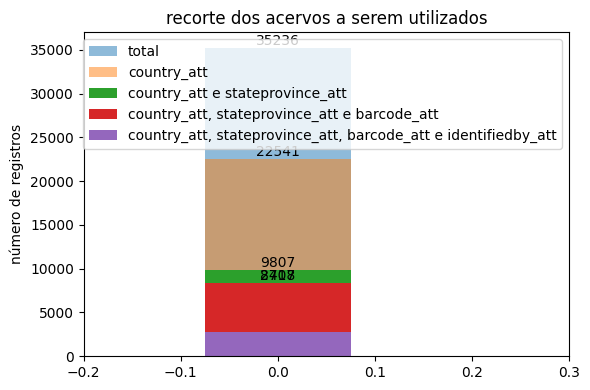

In [41]:
plt.figure(figsize=(6, 4))

x = [0]

plt.bar(
    x,
    [total_registros],
    alpha=0.5,
    width=0.15,
    label='total'
)

plt.bar(
    x,
    [registros_country],
    alpha=0.5,
    width=0.15,
    label='country_att'
)

plt.bar(
    x,
    [registros_country_state],
    width=0.15,
    label='country_att e stateprovince_att'
)

plt.bar(
    x,
    [registros_country_state_barcode],
    width=0.15,
    label='country_att, stateprovince_att e barcode_att'
)

plt.bar(
    x,
    [registros_country_state_barcode_e_identificador],
    width=0.15,
    label='country_att, stateprovince_att, barcode_att e identifiedby_att'
)

plt.xlim(-0.2, 0.3)
plt.ylabel('número de registros')
plt.title('recorte dos acervos a serem utilizados')
plt.legend()

plt.text(0, total_registros, str(total_registros), ha='center', va='bottom')
plt.text(0, registros_country, str(registros_country), ha='center', va='bottom')
plt.text(0, registros_country_state, str(registros_country_state), ha='center', va='bottom')
plt.text(0, registros_country_state_barcode, str(registros_country_state_barcode), ha='center', va='bottom')
plt.text(0, registros_country_state_barcode, str(registros_country_state_barcode_e_identificador), ha='center', va='bottom')

plt.tight_layout()
plt.show()

#### Sexta etapa: nomes científicos

In [51]:
conn = mysql.connector.connect(**db_config)
cursor = conn.cursor()

requisito = "country_att"
requisito2 = "stateprovince_att"
requisito3 = "barcode_att"
requisito4 = "identifiedby_att"
coluna = "scientificname"
table = table

sql = f"""SELECT {coluna} FROM {table} WHERE {coluna} IS NOT NULL AND {requisito} IS NOT NULL AND {requisito2} IS NOT NULL AND {requisito3} IS NOT NULL AND {requisito4} IS NOT NULL GROUP BY {coluna}"""

cursor.execute(sql)
resultados = cursor.fetchall()

cursor.close()
conn.close()

nomes = [r[0] for r in resultados if r[0]]

df = pd.DataFrame({"scientificname": nomes})

csv_buffer = StringIO()
df.to_csv(csv_buffer, index=False)
csv_buffer.seek(0)

0

In [ ]:
tabela = input("informe o nome da tabela que contém o nome científico ATUAL das plantas: ").strip()
coluna = input("informe o nome da coluna PRÉ-CRIADA que armazenará o NOVO nome científico das plantas: ").strip()
status = input("informe o nome da coluna PRÉ-CRIADA que armazenará o status do nome científico ATUAL das plantas: ").strip()
max_distance = input("informe a margem de erro máxima para erros gramaticais e afina (padrão 0.1): ").strip()
if max_distance:
    try:
        max_distance = float(max_distance)
        # print(f"executando sinonimos.perform_lcvp_fuzzy_search(--csv {csv} --txt {txt} --max_distance {max_distance})...\n")
    except ValueError:
        print("valor inválido para margem de erro. usando valor padrão de 0.1\n")
        max_distance = 0.1
else:
    max_distance = 0.1
specieslink = species_link(api_key=api_key)

csv_buffer.seek(0)
lines = csv_buffer.read().splitlines()

# remove linhas vazias
lines = [line.strip() for line in lines if line.strip()]

# remove header se existir
if lines and lines[0].lower() in ("scientificname", "scientific_name"):
    lines = lines[1:]

if not lines:
    raise RuntimeError("CSV não contém nomes científicos válidos após limpeza")

csv_content = "\n".join(lines) + "\n"

with tempfile.NamedTemporaryFile(
    mode="w",
    suffix=".csv",
    delete=False,
    encoding="utf-8"
) as tmp:
    tmp.write(csv_content)
    tmp_path = tmp.name


print(f"executando sinonimos.perform_lcvp_fuzzy_search_per_line(--csv {tmp_path} --tabela {tabela} --coluna {coluna} --status {status})...\n")

fuzzy_line = perform_lcvp_fuzzy_search_per_line(
    csv_file=tmp_path, db_config=db_config, tabela=tabela, coluna=coluna, specieslink=specieslink, status=status, max_distance=max_distance
)
# if fuzzy_line:
#     print("\nverificando com o LCVP...")

os.remove(tmp_path)

executando sinonimos.perform_lcvp_fuzzy_search_per_line(--csv C:\Users\Dell\AppData\Local\Temp\tmpdk3g9qik.csv --tabela registros_biodiversidade --coluna scientificname_att --status status_plantas)...

processando: Oxalis euphorbioides...
atualizando 'Oxalis euphorbioides' para 'Oxalis divaricata Mart. ex Zucc.' por ter status 'synonym'
conexão bem-sucedida
query gerada para UPDATE: 
                UPDATE teste_pipeline.registros_biodiversidade
                SET scientificname_att = %s
                WHERE scientificname = %s
            
valores para UPDATE: ['Oxalis divaricata Mart. ex Zucc.', 'Oxalis euphorbioides']
50 registro(s) atualizado(s).
conexão encerrada
conexão bem-sucedida
query gerada para UPDATE: 
                UPDATE teste_pipeline.registros_biodiversidade
                SET status_plantas = %s
                WHERE scientificname = %s
            
valores para UPDATE: ['synonym', 'Oxalis euphorbioides']
50 registro(s) atualizado(s).
conexão encerrada
processand

R[write to console]: Error: splist should include only binomial names, please check the following names: 'Oxalis'

R[write to console]: In addition: 
R[write to console]: Warning messages:

R[write to console]: 1: No match found for 'OXALIS ITAMARAJUENSIS'. 

R[write to console]: 2: No match found for 'OXALIS JACOBINENSIS'. 

R[write to console]: 3: No match found for 'OXALIS ANIMARUM'. 

R[write to console]: 4: No match found for 'OXALIS AMORIMII'. 

R[write to console]: 5: No match found for 'AVERROHA BILIMBI'. 

R[write to console]: 6: No match found for 'OXALIS CORNICARPA'. 



718 registro(s) atualizado(s).
conexão encerrada
processando: Oxalis...
erro ao processar 'Oxalis': Error: splist should include only binomial names, please check the following names: 'Oxalis'

processando: Oxalis paranaensis...
'Oxalis paranaensis' tem pelo menos uma entrada com status 'accepted', não será atualizado
conexão bem-sucedida
query gerada para UPDATE: 
                UPDATE teste_pipeline.registros_biodiversidade
                SET status_plantas = %s
                WHERE scientificname = %s
            
valores para UPDATE: ['accepted', 'Oxalis paranaensis']
84 registro(s) atualizado(s).
conexão encerrada
processando: Oxalis sellowii...
'Oxalis sellowii' tem pelo menos uma entrada com status 'accepted', não será atualizado
conexão bem-sucedida
query gerada para UPDATE: 
                UPDATE teste_pipeline.registros_biodiversidade
                SET status_plantas = %s
                WHERE scientificname = %s
            
valores para UPDATE: ['accepted', 'Oxalis se

In [54]:
conn = mysql.connector.connect(**db_config)
cursor = conn.cursor()

sql = """
SELECT
    COUNT(*) AS total_registros,
    SUM(country_att IS NOT NULL) AS com_country,
    SUM(country_att IS NOT NULL AND stateprovince_att IS NOT NULL) AS com_country_e_state,
    SUM(country_att IS NOT NULL AND stateprovince_att IS NOT NULL AND barcode_att IS NOT NULL) as com_country_state_e_barcode,
    SUM(country_att IS NOT NULL AND stateprovince_att IS NOT NULL AND barcode_att IS NOT NULL AND identifiedby_att IS NOT NULL) as com_country_state_barcode_e_identificador,
    SUM(country_att IS NOT NULL AND stateprovince_att IS NOT NULL AND barcode_att IS NOT NULL AND identifiedby_att IS NOT NULL AND status_plantas = "accepted" OR status_plantas = "synonym") as com_country_state_barcode_identificador_nome
FROM registros_biodiversidade
"""

cursor.execute(sql)
total_registros, registros_country, registros_country_state, registros_country_state_barcode, registros_country_state_barcode_e_identificador, registros_country_state_barcode_identificador_nome = cursor.fetchone()

cursor.close()
conn.close()

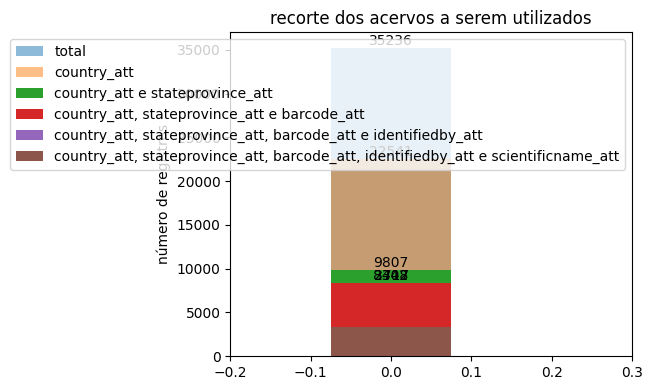

In [ ]:
plt.figure(figsize=(6, 4))

x = [0]

plt.bar(
    x,
    [total_registros],
    alpha=0.5,
    width=0.15,
    label='total'
)

plt.bar(
    x,
    [registros_country],
    alpha=0.5,
    width=0.15,
    label='country_att'
)

plt.bar(
    x,
    [registros_country_state],
    width=0.15,
    label='country_att e stateprovince_att'
)

plt.bar(
    x,
    [registros_country_state_barcode],
    width=0.15,
    label='country_att, stateprovince_att e barcode_att'
)

plt.bar(
    x,
    [registros_country_state_barcode_e_identificador],
    width=0.15,
    label='country_att, stateprovince_att, barcode_att e identifiedby_att'
)

plt.bar(
    x,
    [registros_country_state_barcode_identificador_nome],
    width=0.15,
    label='country_att, stateprovince_att, barcode_att, identifiedby_att e scientificname_att'
)

plt.xlim(-0.2, 0.3)
plt.ylabel('número de registros')
plt.title('recorte dos acervos a serem utilizados')
plt.legend()

plt.text(0, total_registros, str(total_registros), ha='center', va='bottom')
plt.text(0, registros_country, str(registros_country), ha='center', va='bottom')
plt.text(0, registros_country_state, str(registros_country_state), ha='center', va='bottom')
plt.text(0, registros_country_state_barcode, str(registros_country_state_barcode), ha='center', va='bottom')
plt.text(0, registros_country_state_barcode, str(registros_country_state_barcode_e_identificador), ha='center', va='bottom')
plt.text(0, registros_country_state_barcode, str(registros_country_state_barcode_identificador_nome), ha='center', va='bottom')

plt.tight_layout()
plt.show()

#### Sétima etapa: imagens

In [2]:
conn = mysql_conn.connect(**db_config)
cursor = conn.cursor()

requisito = "country_att"
requisito2 = "stateprovince_att"
requisito3 = "barcode_att"
requisito4 = "identifiedby_att"
coluna = "barcode"
table = "registros_biodiversidade"

sql = f"""SELECT {coluna} FROM {table} WHERE {coluna} IS NOT NULL AND {requisito} IS NOT NULL AND {requisito2} IS NOT NULL AND {requisito3} IS NOT NULL AND {requisito4} IS NOT NULL"""

cursor.execute(sql)
resultados = cursor.fetchall()

for resultado in resultados:
    print(resultado[0])

cursor.close()
conn.close()

barcodes = [r[0] for r in resultados if r[0]]

df = pd.DataFrame({"barcode": barcodes})

with tempfile.NamedTemporaryFile(
    mode="w",
    suffix=".csv",
    delete=False,
    encoding="utf-8"
) as tmp:
    df.to_csv(tmp.name, index=False)
    csv_path = tmp.name

NameError: name 'db_config' is not defined

In [ ]:
familia = input("informe o nome da família das plantas para salvar o arquivo de saída: ").strip()
csv = csv_path
try:
    print(f"\nexecutando crawler para a família '{familia}' com coleta de URLs...\n")
    print("\né normal que demore !!!\n")
    subprocess.run([f'python', 'downloader-specieslink-master/main.py', '--familia', familia, '--csv', csv])
    print("\ncoleta de URLs concluída com sucesso.\n")
except Exception as e:
    print(f"\nocorreu um erro ao executar o crawler: {e}\n")


executando crawler para a família 'Oxalidaceae' com coleta de URLs...


coleta de URLs concluída com sucesso.



In [ ]:
csv = input("caminho para o CSV com URLs gerado no passo anterior: ").strip()
output_imagens = input("diretório de saída das imagens (vai criar se não tiver): ").strip()
try:
    print(f"\nexecutando download das imagens para saída em '{output_imagens}'...\n")
    print("<!!!> ATENÇÃO: PROCESSO DEMORADO - PODE DEMORAR DIAS! <!!!>")
    subprocess.run(['python', 'downloader-specieslink-master/use-dezoomify-rs.py', '--input', csv, '--output', output_imagens])
    print("\ndownload das imagens concluído com sucesso.\n")
except Exception as e:
    print(f"\nocorreu um erro ao baixar imagens: {e}\n")


executando download das imagens para saída em 'teste'...

<!!!> ATENÇÃO: PROCESSO DEMORADO - PODE DEMORAR DIAS! <!!!>

download das imagens concluído com sucesso.



In [ ]:

# barcodes_teste = [
# "HACAM00005734",
# "HACAM00000783",
# "HACAM00002799",
# "JOI010244",
# "JOI010280",
# "JOI000758",
# "JOI000759",
# "JOI000761",
# "TEPB0022936",
# "TEPB0028155",
# "TEPB0033104",
# "TEPB0008178",
# "TEPB0032651",
# "TEPB0023893",
# "SHPR004956",
# "SHPR004704",
# "COR00016423",
# "TEPB0032649",
# "TEPB0032650",
# "TEPB0013617",
# "TEPB0016843",
# "TEPB0022808",
# "TEPB0023964",
# "TEPB0029587",
# "TEPB0032653"]

# with tempfile.NamedTemporaryFile(mode="w", suffix=".csv", delete=False, encoding="utf-8") as tmp_teste:
#     df_teste = pd.DataFrame({"barcode": barcodes_teste})
#     df_teste.to_csv(tmp_teste.name, index=False)
#     csv_teste_path = os.path.abspath(tmp_teste.name)

# familia = input("informe o nome da família (TESTE): ").strip()

# # Caminhos que você já definiu
# script_path = os.path.abspath(os.path.join('..', 'ferramenta_herbcore', 'downloader-specieslink-master', 'main.py'))
# working_dir = os.path.dirname(script_path)
# pipeline_dir = os.getcwd()

# arquivos_antes = set(os.listdir(working_dir))

# with tempfile.NamedTemporaryFile(mode="w", suffix=".csv", delete=False, encoding="utf-8") as tmp_teste:
#     pd.DataFrame({"barcode": barcodes_teste}).to_csv(tmp_teste.name, index=False)
#     csv_teste_path = os.path.abspath(tmp_teste.name)

# try:
#     print(f"\n[MODO TESTE] Executando crawler para 3 barcodes específicos...")
    
#     # Rodando o subprocess com o CSV de teste
#     result = subprocess.run(
#         ['python', script_path, '--familia', familia, '--csv', csv_teste_path], 
#         cwd=working_dir, 
#         check=True
#     )
    
# # 5. Mapear arquivos depois da execução
#     arquivos_depois = set(os.listdir(working_dir))
#     novos_arquivos = arquivos_depois - arquivos_antes

#     print(f"Arquivos novos detectados na pasta do crawler: {novos_arquivos}")

#     arquivo_encontrado = False
#     for arquivo in novos_arquivos:
#         # Debug para ver o que está passando no teste
#         print(f"Analisando arquivo: {arquivo}")
        
#         # Filtro: Contém o nome da família (independente de maiúsculas) E é um CSV
#         if familia.lower() in arquivo.lower() and arquivo.lower().endswith('.csv'):
#             caminho_origem = os.path.join(working_dir, arquivo)
#             caminho_destino = os.path.join(pipeline_dir, arquivo)
            
#             shutil.move(caminho_origem, caminho_destino)
#             print(f"✅ SUCESSO! Movido: {arquivo}")
#             arquivo_encontrado = True
#             break

#     if not arquivo_encontrado:
#         print("❌ Falha na detecção automática.")
#         print(f"Conteúdo atual da pasta do crawler: {os.listdir(working_dir)}")

# except Exception as e:
#     print(f"\nocorreu um erro ao executar o crawler: {e}\n")

# finally:
#     # Limpa o arquivo temporário de teste
#     if os.path.exists(csv_teste_path):
#         os.remove(csv_teste_path)